In [1]:
import os
import torch
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import Dataset
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
DRIFT_ROUND = 50

# MNIST

In [2]:
plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/adaptive-fluid/fluid-fed-ul/src/plots/mnist"

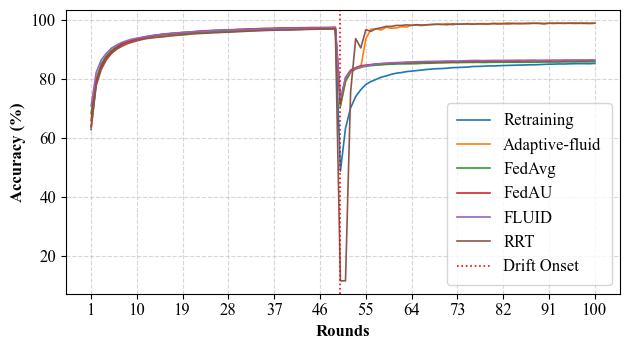

In [3]:
import os
import json
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set font style for IEEE

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12
})

# List of JSON files
json_files = [f for f in os.listdir(plot_dir) if f.endswith(".json")]

# Map filenames to plot labels
label_map = {
    "drift": "FedAvg",
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID"
}

global_accuracies = []
labels = []

for file in json_files:
    file_path = os.path.join(plot_dir, file)
    
    # Extract mode from filename: "{mode}_results.json"
    mode = file.replace("_results.json", "").replace("mnist_", "")
    label = label_map.get(mode.lower(), mode.capitalize())
    labels.append(label)

    with open(file_path, "r") as f:
        data = json.load(f)

    # Collect accuracies for each client
    client_accuracies = []
    for client_id, rounds in data.items():
        acc_list = []
        for round_id, round_data in sorted(rounds.items(), key=lambda x: int(x[0])):
            metrics_str = round_data["eval_metrics"]
            metrics = ast.literal_eval(metrics_str)  # convert string to dict
            acc_list.append(metrics["accuracy"])
        client_accuracies.append(acc_list)

    # Average across clients (round-wise)
    avg_accuracies = np.mean(client_accuracies, axis=0)
    global_accuracies.append(avg_accuracies)

# Colors
client_colors = sns.color_palette("tab10", len(global_accuracies))

# Plot
plt.figure(figsize=(6.4, 3.6))  # IEEE double column width

for i, acc in enumerate(global_accuracies):
    rounds = range(1, len(acc) + 1)
    acc_percent = [a * 100 for a in acc]
    
    # Dotted line for FedAvg without drift, solid otherwise
    linestyle = '--' if labels[i] == "FedAvg without drift" else '-'
    
    plt.plot(rounds, acc_percent,
             label=labels[i],
             linewidth=1.2,
             linestyle=linestyle,
             color=client_colors[i])

plt.xlabel("Rounds", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=12, fontweight="bold")

plt.axvline(
    DRIFT_ROUND,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label="Drift Onset"
)

plt.xticks(
    ticks=np.linspace(1, len(global_accuracies[0]), 12, dtype=int),
    fontsize=12
)
plt.yticks(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(loc="lower right", frameon=True, borderpad=0.6, framealpha=0.8)
plt.tight_layout()
plt.savefig("/Users/amankumar/Documents/MS/Sem4/Thesis/plots/mnist_global_accuracy.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [4]:
import os
import json
import ast
import numpy as np
import pandas as pd

# ------------------ Config ------------------
DRIFT_ROUND = 50

label_map = {
    "drift": "FedAvg",
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID"
}

rows = []

# ------------------ Iterate JSON files ------------------
json_files = [f for f in os.listdir(plot_dir) if f.endswith(".json")]

for file in json_files:
    file_path = os.path.join(plot_dir, file)

    mode = file.replace("_results.json", "").replace("mnist_", "")
    method = label_map.get(mode.lower(), mode.capitalize())

    with open(file_path, "r") as f:
        data = json.load(f)

    client_accuracies = []

    # Collect per-client global accuracy curves
    for client_id, rounds in data.items():
        acc = []
        for r, rdata in sorted(rounds.items(), key=lambda x: int(x[0])):
            metrics = ast.literal_eval(rdata["eval_metrics"])
            acc.append(metrics["accuracy"] * 100)
        client_accuracies.append(acc)

    client_accuracies = np.array(client_accuracies)

    # ------------------ Metrics ------------------
    acc_49 = client_accuracies[:, DRIFT_ROUND - 2].mean()
    acc_50 = client_accuracies[:, DRIFT_ROUND - 1].mean()
    final_acc = client_accuracies[:, -1].mean()
    dip = acc_50 - acc_49

    rows.append({
        "Method": method,
        "Accuracy @ Round 49 (%)": round(acc_49, 2),
        "Accuracy @ Round 50 (%)": round(acc_50, 2),
        "Dip (49 → 50) (%)": round(dip, 2),
        "Final Accuracy (%)": round(final_acc, 2)
    })

# ------------------ Create Table ------------------
df = pd.DataFrame(rows)
df = df.sort_values("Final Accuracy (%)", ascending=False)

df.sort_values("Final Accuracy (%)")

,Method,Accuracy @ Round 49 (%),Accuracy @ Round 50 (%),Dip (49 → 50) (%),Final Accuracy (%)
0,Retraining,97.51,48.81,-48.70,85.37
2,FedAvg,97.14,70.83,-26.31,85.94
3,FedAU,97.68,72.41,-25.27,86.39
4,FLUID,97.50,73.31,-24.19,86.56
5,RRT,97.17,11.55,-85.62,99.01
1,Adaptive-fluid,97.23,71.01,-26.22,99.09


# FMNIST

In [9]:
plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/adaptive-fluid/fluid-fed-ul/src/plots/fmnist"

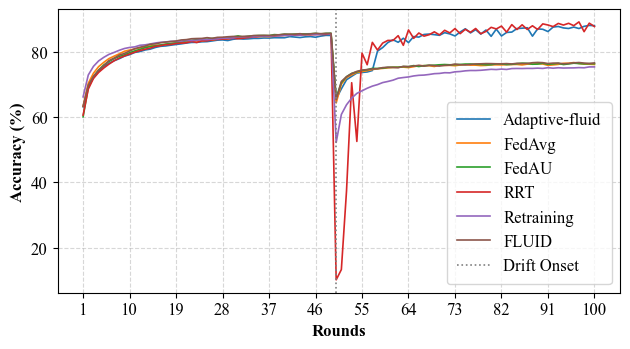

In [6]:
import os
import json
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set font style for IEEE

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12
})

# List of JSON files
json_files = [f for f in os.listdir(plot_dir) if f.endswith(".json")]

# Map filenames to plot labels
label_map = {
    "drift": "FedAvg",
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID"
}

global_accuracies = []
labels = []

for file in json_files:
    file_path = os.path.join(plot_dir, file)
    
    # Extract mode from filename: "{mode}_results.json"
    mode = file.replace("_results.json", "").replace("fashion_mnist_", "")
    label = label_map.get(mode.lower(), mode.capitalize())
    labels.append(label)

    with open(file_path, "r") as f:
        data = json.load(f)

    # Collect accuracies for each client
    client_accuracies = []
    for client_id, rounds in data.items():
        acc_list = []
        for round_id, round_data in sorted(rounds.items(), key=lambda x: int(x[0])):
            metrics_str = round_data["eval_metrics"]
            metrics = ast.literal_eval(metrics_str)  # convert string to dict
            acc_list.append(metrics["accuracy"])
        client_accuracies.append(acc_list)

    # Average across clients (round-wise)
    avg_accuracies = np.mean(client_accuracies, axis=0)
    global_accuracies.append(avg_accuracies)

# Colors
client_colors = sns.color_palette("tab10", len(global_accuracies))

# Plot
plt.figure(figsize=(6.4, 3.6))  # IEEE double column width

for i, acc in enumerate(global_accuracies):
    rounds = range(1, len(acc) + 1)
    acc_percent = [a * 100 for a in acc]
    
    # Dotted line for FedAvg without drift, solid otherwise
    linestyle = '--' if labels[i] == "FedAvg without drift" else '-'
    
    plt.plot(rounds, acc_percent,
             label=labels[i],
             linewidth=1.2,
             linestyle=linestyle,
             color=client_colors[i])

plt.xlabel("Rounds", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=12, fontweight="bold")

plt.axvline(
    DRIFT_ROUND,
    color="grey",
    linestyle=":",
    linewidth=1.2,
    label="Drift Onset"
)

plt.xticks(
    ticks=np.linspace(1, len(global_accuracies[0]), 12, dtype=int),
    fontsize=12
)
plt.yticks(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(loc="lower right", frameon=True, borderpad=0.6, framealpha=0.8)
plt.tight_layout()
plt.savefig("/Users/amankumar/Documents/MS/Sem4/Thesis/plots/fmnist_global_accuracy.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [7]:
import os
import json
import ast
import numpy as np
import pandas as pd

# ------------------ Config ------------------
DRIFT_ROUND = 50

label_map = {
    "drift": "FedAvg",
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID"
}

rows = []

# ------------------ Iterate JSON files ------------------
json_files = [f for f in os.listdir(plot_dir) if f.endswith(".json")]

for file in json_files:
    file_path = os.path.join(plot_dir, file)

    mode = file.replace("_results.json", "").replace("fashion_mnist_", "")
    method = label_map.get(mode.lower(), mode.capitalize())

    with open(file_path, "r") as f:
        data = json.load(f)

    client_accuracies = []

    # Collect per-client global accuracy curves
    for client_id, rounds in data.items():
        acc = []
        for r, rdata in sorted(rounds.items(), key=lambda x: int(x[0])):
            metrics = ast.literal_eval(rdata["eval_metrics"])
            acc.append(metrics["accuracy"] * 100)
        client_accuracies.append(acc)

    client_accuracies = np.array(client_accuracies)

    # ------------------ Metrics ------------------
    acc_49 = client_accuracies[:, DRIFT_ROUND - 2].mean()
    acc_50 = client_accuracies[:, DRIFT_ROUND - 1].mean()
    final_acc = client_accuracies[:, -1].mean()
    dip = acc_50 - acc_49

    rows.append({
        "Method": method,
        "Accuracy @ Round 49 (%)": round(acc_49, 2),
        "Accuracy @ Round 50 (%)": round(acc_50, 2),
        "Dip (49 → 50) (%)": round(dip, 2),
        "Final Accuracy (%)": round(final_acc, 2)
    })

# ------------------ Create Table ------------------
df = pd.DataFrame(rows)
df = df.sort_values("Final Accuracy (%)", ascending=False)

df.sort_values("Final Accuracy (%)")

,Method,Accuracy @ Round 49 (%),Accuracy @ Round 50 (%),Dip (49 → 50) (%),Final Accuracy (%)
4,Retraining,85.56,52.31,-33.26,75.51
1,FedAvg,85.65,64.44,-21.21,76.26
2,FedAU,85.85,66.06,-19.79,76.49
5,FLUID,85.83,65.41,-20.42,76.73
3,RRT,85.69,10.08,-75.61,87.92
0,Adaptive-fluid,85.17,65.68,-19.50,88.18


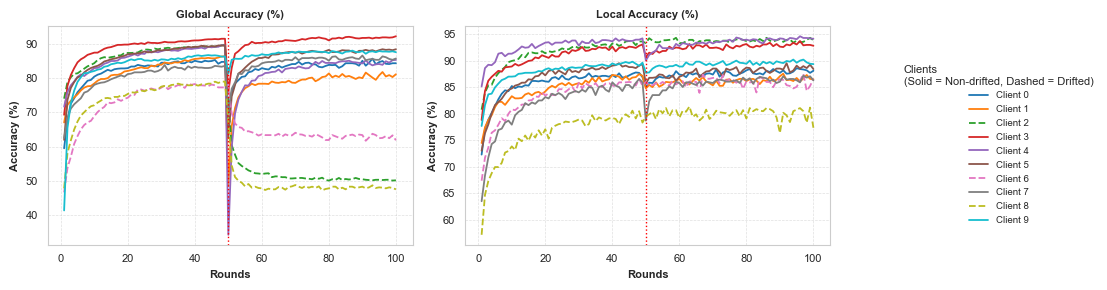

In [36]:
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------ Style ------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "legend.title_fontsize": 8
})
sns.set_style("whitegrid")

# ------------------ Config ------------------
DRIFT_ROUNDS = [50]

# ------------------ Load JSON ------------------
with open(plot_dir + "/fashion_mnist_fedau_results.json") as f:
    results = json.load(f)

client_ids = sorted(results.keys(), key=int)
colors = sns.color_palette("tab10", len(client_ids))

# ------------------ Figure ------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs = axs.flatten()

# ------------------ Plot (RAW, no smoothing) ------------------
for idx, client_id in enumerate(client_ids):
    client_data = results[client_id]
    rounds = sorted(client_data.keys(), key=int)

    local_acc, global_acc, round_nums = [], [], []
    drifted = False

    for r in rounds:
        train = ast.literal_eval(client_data[r]["train_metrics"])
        eval_ = ast.literal_eval(client_data[r]["eval_metrics"])

        local_acc.append(train["train_accuracy"] * 100)
        global_acc.append(eval_["accuracy"] * 100)
        round_nums.append(int(r))

        drifted |= train["is_drifted"]

    linestyle = "--" if drifted else "-"

    axs[0].plot(
        round_nums,
        global_acc,
        color=colors[idx],
        linewidth=1.3,
        linestyle=linestyle,
        label=f"Client {client_id}"
    )

    axs[1].plot(
        round_nums,
        local_acc,
        color=colors[idx],
        linewidth=1.3,
        linestyle=linestyle
    )

# ------------------ Drift markers ------------------
for ax in axs:
    for d in DRIFT_ROUNDS:
        ax.axvline(
            x=d,
            color="red",
            linestyle=":",
            linewidth=1
        )

# ------------------ Formatting ------------------
axs[0].set_title("Global Accuracy (%)", fontweight="bold")
axs[1].set_title("Local Accuracy (%)", fontweight="bold")

for ax in axs:
    ax.set_xlabel("Rounds", fontweight="bold")
    ax.set_ylabel("Accuracy (%)", fontweight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax.margins(y=0.05)   # soft padding, no clipping

# ------------------ Legend ------------------
fig.legend(
    title="Clients\n(Solid = Non-drifted, Dashed = Drifted)",
    loc="center left",
    bbox_to_anchor=(0.9, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


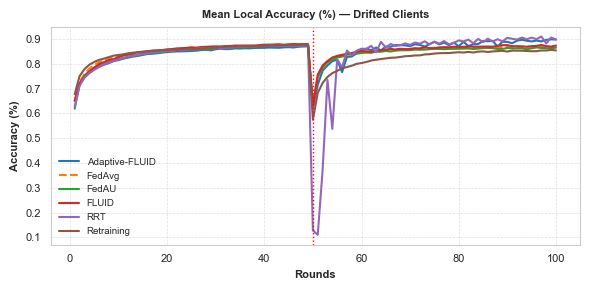

In [2]:
import os
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------ Style ------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7
})
sns.set_style("whitegrid")

# ------------------ Config ------------------
DRIFT_ROUNDS = [50]
DRIFTED_CLIENTS = {"0", "1", "3", "4", "5", "7", "9"}

# Map filenames (modes) to plot labels
label_map = {
    "drift": "FedAvg",
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID"
}

# ------------------ Collect all JSON files ------------------
# (Filter to your experiment, e.g. fashion_mnist_*.json)
json_files = sorted(
    f for f in os.listdir(plot_dir)
    if f.endswith(".json") and f.startswith("fashion_mnist_")
)

series = []   # list of (round_nums, mean_local_acc, label)

for file in json_files:
    file_path = os.path.join(plot_dir, file)

    # Extract mode from filename: "fashion_mnist_<mode>_results.json"
    mode = file.replace("_results.json", "").replace("fashion_mnist_", "")
    label = label_map.get(mode.lower(), mode.capitalize())

    # ------------------ Load JSON ------------------
    with open(file_path, "r") as f:
        results = json.load(f)

    # ------------------ Collect local accuracies per round (drifted clients only) ------------------
    round_to_accs = {}

    for client_id in DRIFTED_CLIENTS:
        # Some files might not have all clients; skip if missing
        if client_id not in results:
            continue

        client_data = results[client_id]
        rounds = sorted(client_data.keys(), key=int)

        for r in rounds:
            train = ast.literal_eval(client_data[r]["eval_metrics"])
            acc = train["accuracy"]

            round_to_accs.setdefault(int(r), []).append(acc)

    if not round_to_accs:
        # No data (e.g., drifted clients missing) -> skip this file
        continue

    # ------------------ Compute mean per round ------------------
    round_nums = sorted(round_to_accs.keys())
    mean_local_acc = [np.mean(round_to_accs[r]) for r in round_nums]

    series.append((round_nums, mean_local_acc, label))

# ------------------ Plot ------------------
fig, ax = plt.subplots(figsize=(6, 3))

# One color per method/file
colors = sns.color_palette("tab10", len(series))

for i, (round_nums, mean_local_acc, label) in enumerate(series):
    # Optional: make FedAvg dashed, others solid
    linestyle = '--' if "FedAvg" in label else '-'

    ax.plot(
        round_nums,
        mean_local_acc,
        linewidth=1.5,
        color=colors[i],
        linestyle=linestyle,
        label=label,
    )

# ------------------ Drift markers ------------------
for d in DRIFT_ROUNDS:
    ax.axvline(x=d, color="red", linewidth=1, linestyle=":")

# ------------------ Formatting ------------------
ax.set_title("Mean Local Accuracy (%) — Drifted Clients", fontweight="bold")
ax.set_xlabel("Rounds", fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontweight="bold")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.margins(y=0.05)

ax.legend(frameon=False)
plt.savefig("/Users/amankumar/Documents/MS/Sem4/Thesis/plots/drifted_client_accuracy.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [12]:
import os
import json
import ast
import numpy as np
import pandas as pd

# ------------------ Config ------------------
DRIFT_ROUND = 50
DRIFTED_CLIENTS = {"0", "1", "3", "4", "5", "7", "9"}

label_map = {
    "drift": "FedAvg",
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID"
}

rows = []

# ------------------ Iterate JSON files ------------------
json_files = [
    f for f in os.listdir(plot_dir)
    if f.endswith(".json") and f.startswith("fashion_mnist_")
]

for file in json_files:
    file_path = os.path.join(plot_dir, file)

    mode = file.replace("_results.json", "").replace("fashion_mnist_", "")
    method = label_map.get(mode.lower(), mode.capitalize())

    with open(file_path, "r") as f:
        data = json.load(f)

    round_to_accs = {}

    # -------- ONLY drifted clients --------
    for client_id in DRIFTED_CLIENTS:
        if client_id not in data:
            continue

        rounds = data[client_id]
        for r_str, rdata in rounds.items():
            r = int(r_str)
            metrics = ast.literal_eval(rdata["eval_metrics"])
            acc = metrics["accuracy"] * 100.0

            round_to_accs.setdefault(r, []).append(acc)

    if not round_to_accs:
        continue

    # -------- Mean accuracy across the 7 clients --------
    round_nums = sorted(round_to_accs.keys())
    mean_acc = np.array([np.mean(round_to_accs[r]) for r in round_nums])

    acc_49 = mean_acc[DRIFT_ROUND - 2]
    acc_50 = mean_acc[DRIFT_ROUND - 1]
    final_acc = mean_acc[-1]
    dip = acc_50 - acc_49

    rows.append({
        "Method": method,
        "Accuracy @ Round 49 (%)": round(acc_49, 2),
        "Accuracy @ Round 50 (%)": round(acc_50, 2),
        "Dip (49 → 50) (%)": round(dip, 2),
        "Final Accuracy (%)": round(final_acc, 2)
    })

# ------------------ Create DataFrame ------------------
df = pd.DataFrame(rows).sort_values(
    "Final Accuracy (%)",
    ascending=False
)

df

,Method,Accuracy @ Round 49 (%),Accuracy @ Round 50 (%),Dip (49 → 50) (%),Final Accuracy (%)
0,Adaptive-FLUID,86.98,62.33,-24.64,89.73
3,RRT,87.54,12.82,-74.72,89.73
5,FLUID,87.91,62.74,-25.17,87.32
2,FedAU,87.46,63.22,-24.24,86.50
1,FedAvg,87.70,62.48,-25.22,86.46
4,Retraining,87.56,57.44,-30.12,85.35


In [11]:
# import json
# import ast
# import pandas as pd

# # ------------------ Config ------------------
# DRIFT_ROUND = 50

# # ------------------ Load JSON ------------------
# with open(plot_dir + "/fashion_mnist_drift_results.json") as f:
#     results = json.load(f)

# rows = []

# # ------------------ Process each client ------------------
# for client_id in sorted(results.keys(), key=int):
#     rounds_data = results[client_id]

#     global_acc = []
#     local_acc = []

#     for r, rdata in sorted(rounds_data.items(), key=lambda x: int(x[0])):
#         train = ast.literal_eval(rdata["train_metrics"])
#         eval_ = ast.literal_eval(rdata["eval_metrics"])

#         global_acc.append(eval_["accuracy"] * 100)
#         local_acc.append(train["train_accuracy"] * 100)

#     # ------------------ Metrics ------------------
#     g_49 = global_acc[DRIFT_ROUND - 2]
#     g_50 = global_acc[DRIFT_ROUND - 1]
#     g_final = global_acc[-1]
#     g_dip = g_50 - g_49

#     l_49 = local_acc[DRIFT_ROUND - 2]
#     l_50 = local_acc[DRIFT_ROUND - 1]
#     l_final = local_acc[-1]
#     l_dip = l_50 - l_49

#     rows.append({
#         "Client": f"Client {client_id}",

#         "Global @49 (%)": round(g_49, 2),
#         "Global @50 (%)": round(g_50, 2),
#         "Global Dip (49→50) (%)": round(g_dip, 2),
#         "Global Final (%)": round(g_final, 2),

#         "Local @49 (%)": round(l_49, 2),
#         "Local @50 (%)": round(l_50, 2),
#         "Local Dip (49→50) (%)": round(l_dip, 2),
#         "Local Final (%)": round(l_final, 2)
#     })

# # ------------------ Create DataFrame ------------------
# pd.DataFrame(rows)

# CIFAR-10

In [40]:
plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/adaptive-fluid/fluid-fed-ul/src/plots/cifar"

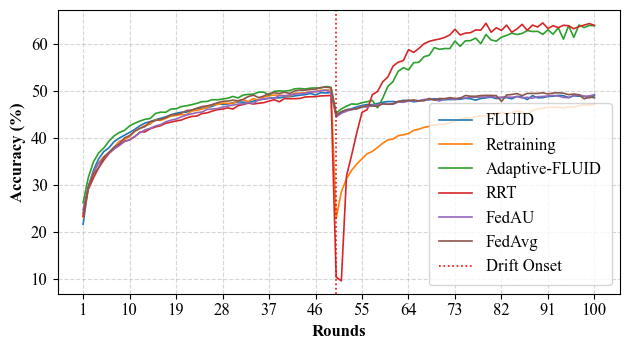

In [41]:
import os
import json
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set font style for IEEE
DRIFT_ROUND = 50

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12
})

# List of JSON files
json_files = [f for f in os.listdir(plot_dir) if f.endswith(".json")]

# Map filenames to plot labels
label_map = {
    "drift": "FedAvg",
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID"
}

global_accuracies = []
labels = []

for file in json_files:
    file_path = os.path.join(plot_dir, file)
    
    # Extract mode from filename: "{mode}_results.json"
    mode = file.replace("_results.json", "").replace("cifar10_", "")
    label = label_map.get(mode.lower(), mode.capitalize())
    labels.append(label)

    with open(file_path, "r") as f:
        data = json.load(f)

    # Collect accuracies for each client
    client_accuracies = []
    for client_id, rounds in data.items():
        acc_list = []
        for round_id, round_data in sorted(rounds.items(), key=lambda x: int(x[0])):
            metrics_str = round_data["eval_metrics"]
            metrics = ast.literal_eval(metrics_str)  # convert string to dict
            acc_list.append(metrics["accuracy"])
        client_accuracies.append(acc_list)

    # Average across clients (round-wise)
    avg_accuracies = np.mean(client_accuracies, axis=0)
    global_accuracies.append(avg_accuracies)

# Colors
client_colors = sns.color_palette("tab10", len(global_accuracies))

# Plot
plt.figure(figsize=(6.4, 3.6))  # IEEE double column width

for i, acc in enumerate(global_accuracies):
    rounds = range(1, len(acc) + 1)
    acc_percent = [a * 100 for a in acc]
    
    # Dotted line for FedAvg without drift, solid otherwise
    linestyle = '--' if labels[i] == "FedAvg without drift" else '-'
    
    plt.plot(rounds, acc_percent,
             label=labels[i],
             linewidth=1.2,
             linestyle=linestyle,
             color=client_colors[i])

plt.xlabel("Rounds", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=12, fontweight="bold")

plt.axvline(
    DRIFT_ROUND,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label="Drift Onset"
)

plt.xticks(
    ticks=np.linspace(1, len(global_accuracies[0]), 12, dtype=int),
    fontsize=12
)
plt.yticks(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(loc="lower right", frameon=True, borderpad=0.6, framealpha=0.8)
plt.tight_layout()
plt.savefig("/Users/amankumar/Documents/MS/Sem4/Thesis/plots/cifar_global_accuracy.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [36]:
label_map = {
    "drift": "FedAvg",
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID"
}

rows = []

# ------------------ Iterate JSON files ------------------
json_files = [f for f in os.listdir(plot_dir) if f.endswith(".json")]

for file in json_files:
    file_path = os.path.join(plot_dir, file)

    mode = file.replace("_results.json", "").replace("cifar10_", "")
    method = label_map.get(mode.lower(), mode.capitalize())

    with open(file_path, "r") as f:
        data = json.load(f)

    client_accuracies = []

    # Collect per-client global accuracy curves
    for client_id, rounds in data.items():
        acc = []
        for r, rdata in sorted(rounds.items(), key=lambda x: int(x[0])):
            metrics = ast.literal_eval(rdata["eval_metrics"])
            acc.append(metrics["accuracy"] * 100)
        client_accuracies.append(acc)

    client_accuracies = np.array(client_accuracies)

    # ------------------ Metrics ------------------
    acc_49 = client_accuracies[:, DRIFT_ROUND - 2].mean()
    acc_50 = client_accuracies[:, DRIFT_ROUND - 1].mean()
    final_acc = client_accuracies[:, -1].mean()
    dip = acc_50 - acc_49

    rows.append({
        "Method": method,
        "Accuracy @ Round 49 (%)": round(acc_49, 2),
        "Accuracy @ Round 50 (%)": round(acc_50, 2),
        "Dip (49 → 50) (%)": round(dip, 2),
        "Final Accuracy (%)": round(final_acc, 2)
    })

# ------------------ Create Table ------------------
df = pd.DataFrame(rows)
df = df.sort_values("Final Accuracy (%)", ascending=False)

df

,Method,Accuracy @ Round 49 (%),Accuracy @ Round 50 (%),Dip (49 → 50) (%),Final Accuracy (%)
3,RRT,49.07,10.31,-38.77,64.04
2,Adaptive-FLUID,50.83,45.32,-5.51,63.94
4,FedAU,49.67,44.51,-5.16,49.25
0,FLUID,49.67,44.90,-4.78,49.03
5,FedAvg,50.71,44.84,-5.87,48.60
1,Retraining,50.22,22.87,-27.36,47.19


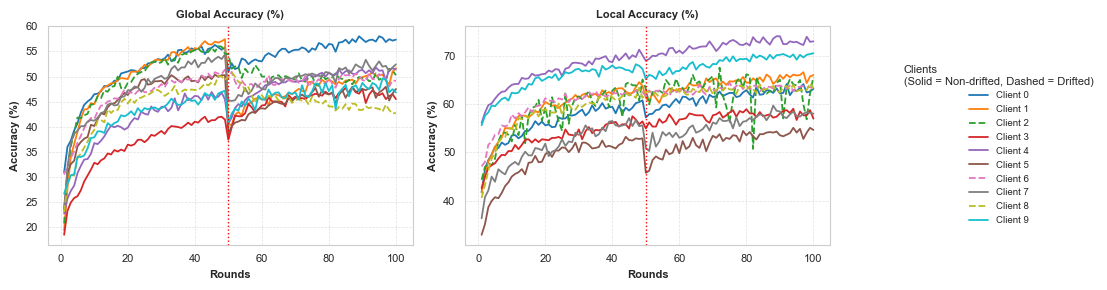

In [27]:
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------ Style ------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "legend.title_fontsize": 8
})
sns.set_style("whitegrid")

# ------------------ Config ------------------
DRIFT_ROUNDS = [50]

# ------------------ Load JSON ------------------
with open(plot_dir + "/cifar10_drift_results.json") as f:
    results = json.load(f)

client_ids = sorted(results.keys(), key=int)
colors = sns.color_palette("tab10", len(client_ids))

# ------------------ Figure ------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs = axs.flatten()

# ------------------ Plot (RAW, no smoothing) ------------------
for idx, client_id in enumerate(client_ids):
    client_data = results[client_id]
    rounds = sorted(client_data.keys(), key=int)

    local_acc, global_acc, round_nums = [], [], []
    drifted = False

    for r in rounds:
        train = ast.literal_eval(client_data[r]["train_metrics"])
        eval_ = ast.literal_eval(client_data[r]["eval_metrics"])

        local_acc.append(train["train_accuracy"] * 100)
        global_acc.append(eval_["accuracy"] * 100)
        round_nums.append(int(r))

        drifted |= train["is_drifted"]

    linestyle = "--" if drifted else "-"

    axs[0].plot(
        round_nums,
        global_acc,
        color=colors[idx],
        linewidth=1.3,
        linestyle=linestyle,
        label=f"Client {client_id}"
    )

    axs[1].plot(
        round_nums,
        local_acc,
        color=colors[idx],
        linewidth=1.3,
        linestyle=linestyle
    )

# ------------------ Drift markers ------------------
for ax in axs:
    for d in DRIFT_ROUNDS:
        ax.axvline(
            x=d,
            color="red",
            linestyle=":",
            linewidth=1
        )

# ------------------ Formatting ------------------
axs[0].set_title("Global Accuracy (%)", fontweight="bold")
axs[1].set_title("Local Accuracy (%)", fontweight="bold")

for ax in axs:
    ax.set_xlabel("Rounds", fontweight="bold")
    ax.set_ylabel("Accuracy (%)", fontweight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax.margins(y=0.05)   # soft padding, no clipping

# ------------------ Legend ------------------
fig.legend(
    title="Clients\n(Solid = Non-drifted, Dashed = Drifted)",
    loc="center left",
    bbox_to_anchor=(0.9, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [28]:
import os
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------ Style ------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7
})
sns.set_style("whitegrid")

# ------------------ Config ------------------
DRIFT_ROUNDS = [50]
DRIFTED_CLIENTS = {"0", "1", "3", "4", "5", "7", "9"}

# Map filenames (modes) to plot labels
label_map = {
    "drift": "FedAvg",
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID"
}

# ------------------ Collect all JSON files ------------------
# (Filter to your experiment, e.g. fashion_mnist_*.json)
json_files = sorted(
    f for f in os.listdir(plot_dir)
    if f.endswith(".json") and f.startswith("cifar10_")
)

series = []   # list of (round_nums, mean_local_acc, label)

for file in json_files:
    file_path = os.path.join(plot_dir, file)

    # Extract mode from filename: "fashion_mnist_<mode>_results.json"
    mode = file.replace("_results.json", "").replace("cifar10_", "")
    label = label_map.get(mode.lower(), mode.capitalize())

    # ------------------ Load JSON ------------------
    with open(file_path, "r") as f:
        results = json.load(f)

    # ------------------ Collect local accuracies per round (drifted clients only) ------------------
    round_to_accs = {}

    for client_id in DRIFTED_CLIENTS:
        # Some files might not have all clients; skip if missing
        if client_id not in results:
            continue

        client_data = results[client_id]
        rounds = sorted(client_data.keys(), key=int)

        for r in rounds:
            train = ast.literal_eval(client_data[r]["eval_metrics"])
            acc = train["eval_accuracy"] * 100.0   # STRICT, percentage

            round_to_accs.setdefault(int(r), []).append(acc)

    if not round_to_accs:
        # No data (e.g., drifted clients missing) -> skip this file
        continue

    # ------------------ Compute mean per round ------------------
    round_nums = sorted(round_to_accs.keys())
    mean_local_acc = [np.mean(round_to_accs[r]) for r in round_nums]

    series.append((round_nums, mean_local_acc, label))

# ------------------ Plot ------------------
fig, ax = plt.subplots(figsize=(6, 3))

# One color per method/file
colors = sns.color_palette("tab10", len(series))

for i, (round_nums, mean_local_acc, label) in enumerate(series):
    # Optional: make FedAvg dashed, others solid
    linestyle = '--' if "FedAvg" in label else '-'

    ax.plot(
        round_nums,
        mean_local_acc,
        linewidth=1.5,
        color=colors[i],
        linestyle=linestyle,
        label=label,
    )

# ------------------ Drift markers ------------------
for d in DRIFT_ROUNDS:
    ax.axvline(x=d, color="red", linewidth=1, linestyle=":")

# ------------------ Formatting ------------------
ax.set_title("Mean Local Accuracy (%) — Drifted Clients", fontweight="bold")
ax.set_xlabel("Rounds", fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontweight="bold")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.margins(y=0.05)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

KeyError: 'train_accuracy'

# Adaptive Fluid Gamma

In [13]:
plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/adaptive-fluid/fluid-fed-ul/src/plots/gamma"

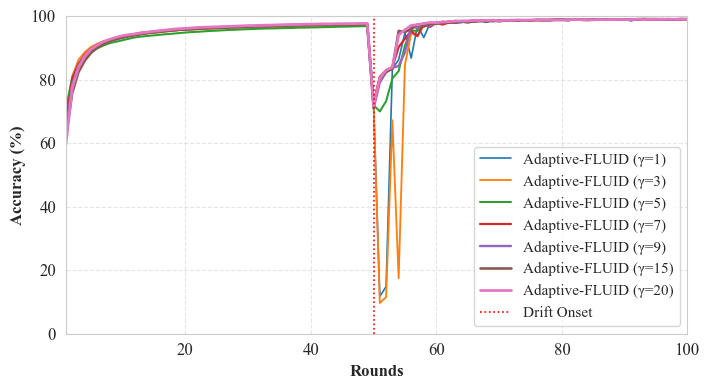

In [14]:
import os
import json
import ast
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# CONFIG
# ----------------------------
DRIFT_ROUND = 50

# IEEE-style fonts
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11
})

# ----------------------------
# LOAD FILES
# ----------------------------
json_files = sorted([
    f for f in os.listdir(plot_dir)
    if f.endswith(".json")
])

global_accuracies = []
labels = []

for file in json_files:
    file_path = os.path.join(plot_dir, file)

    # Extract gamma from filename
    # mnist_adaptive-fluid_results_05.json → γ = 0.5
    match = re.search(r"results_(\d+)", file)
    gamma = int(match.group(1))
    labels.append(f"Adaptive-FLUID (γ={gamma})")

    with open(file_path, "r") as f:
        data = json.load(f)

    # Collect per-client accuracies
    client_accuracies = []

    for client_id, rounds in data.items():
        acc_list = []
        for round_id, round_data in sorted(rounds.items(), key=lambda x: int(x[0])):
            metrics = ast.literal_eval(round_data["eval_metrics"])
            acc_list.append(metrics["accuracy"])
        client_accuracies.append(acc_list)

    # Global model = mean across clients (round-wise)
    global_accuracies.append(np.mean(client_accuracies, axis=0))

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(7.2, 4.0))

colors = sns.color_palette("tab10", len(global_accuracies))
linewidths = np.linspace(1.2, 2.0, len(global_accuracies))

for i, acc in enumerate(global_accuracies):
    rounds = np.arange(1, len(acc) + 1)
    acc_percent = np.array(acc) * 100

    plt.plot(
        rounds,
        acc_percent,
        label=labels[i],
        linewidth=linewidths[i],
        color=colors[i]   # SOLID lines only
    )

# Drift marker (kept subtle but visible)
plt.axvline(
    DRIFT_ROUND,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label="Drift Onset"
)

# Axes & grid
plt.xlabel("Rounds", fontweight="bold")
plt.ylabel("Accuracy (%)", fontweight="bold")

plt.xlim(1, len(global_accuracies[0]))
plt.ylim(0, 100)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend(loc="lower right", frameon=True)
plt.tight_layout()

plt.savefig("/Users/amankumar/Documents/MS/Sem4/Thesis/plots/lambda_schedule.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [45]:
plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/adaptive-fluid/fluid-fed-ul/src/plots"

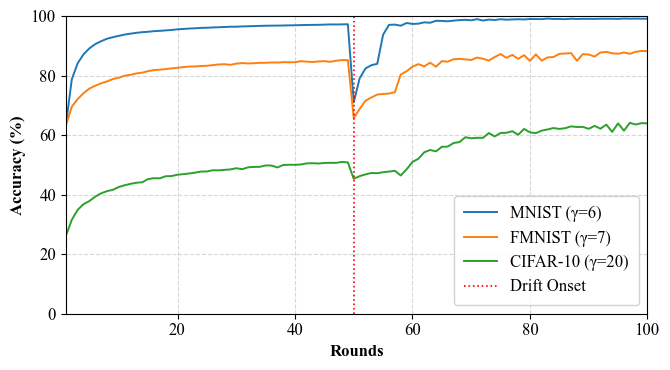

In [46]:
import os
import json
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# CONFIG
# ----------------------------
DRIFT_ROUND = 50

# Root folder that contains mnist/, fmnist/, cifar/
# Example:
# plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/plots/clients"
# and inside it: mnist/, fmnist/, cifar/
# Each subfolder contains the single file you listed.
# plot_dir = "..."

paths = {
    "MNIST (γ=6)":   os.path.join(plot_dir, "mnist",  "mnist_adaptive-fluid_results.json"),
    "FMNIST (γ=7)":  os.path.join(plot_dir, "fmnist", "fashion_mnist_adaptive-fluid_results.json"),
    "CIFAR-10 (γ=20)": os.path.join(plot_dir, "cifar", "cifar10_adaptive-fluid_results.json"),
}

# IEEE-style fonts
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12
})

def load_global_accuracy(json_path: str) -> np.ndarray:
    """Load per-client accuracies from your JSON format and return global mean per round."""
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"Missing file: {json_path}")

    with open(json_path, "r") as f:
        data = json.load(f)

    client_accuracies = []
    for _, rounds in data.items():
        acc_list = []
        for round_id, round_data in sorted(rounds.items(), key=lambda x: int(x[0])):
            metrics = ast.literal_eval(round_data["eval_metrics"])
            acc_list.append(float(metrics["accuracy"]))
        client_accuracies.append(acc_list)

    # shape: (num_clients, num_rounds)
    client_accuracies = np.array(client_accuracies, dtype=float)
    return np.mean(client_accuracies, axis=0)  # (num_rounds,)

# ----------------------------
# LOAD + ALIGN LENGTHS
# ----------------------------
series = {}
min_len = None

for label, p in paths.items():
    acc = load_global_accuracy(p) * 100.0  # convert to %
    series[label] = acc
    min_len = len(acc) if min_len is None else min(min_len, len(acc))

# Truncate to same length so curves align
for label in series:
    series[label] = series[label][:min_len]

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(6.8, 3.8))

colors = sns.color_palette("tab10", n_colors=len(series))
for (label, acc), c in zip(series.items(), colors):
    rounds = np.arange(1, min_len + 1)
    plt.plot(rounds, acc, label=label, linewidth=1.4, color=c)

# Drift marker
plt.axvline(
    DRIFT_ROUND,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label="Drift Onset"
)

plt.xlabel("Rounds", fontweight="bold")
plt.ylabel("Accuracy (%)", fontweight="bold")

plt.xlim(1, min_len)
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.5)

plt.legend(loc="lower right", frameon=True, borderpad=0.6, framealpha=0.85)
plt.tight_layout()

# Save wherever you want
plt.savefig("/Users/amankumar/Documents/MS/Sem4/Thesis/plots/adaptive_fluid_across_datasets.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [15]:
import pandas as pd
import numpy as np
import re

DRIFT_ROUND = 50
TOL = 0.5  # 0.5% of final accuracy

def recovery_round(acc_percent: np.ndarray, drift_round: int = 50, tol: float = 0.5) -> float:
    """
    Return the earliest round t (1-indexed) >= drift_round where acc stays within tol of final
    for all subsequent rounds. If none found, return np.nan.
    """
    final = float(acc_percent[-1])
    within = np.abs(acc_percent - final) <= tol

    # Search from drift round onward (convert to 0-index)
    start_idx = drift_round - 1
    for idx in range(start_idx, len(acc_percent)):
        if within[idx] and np.all(within[idx:]):
            return idx + 1  # back to 1-indexed rounds
    return np.nan

rows = []

for file, acc in zip(json_files, global_accuracies):
    # Extract gamma from filename
    match = re.search(r"results_(\d+)", file)
    if not match:
        continue
    gamma = int(match.group(1))

    # Convert to percent
    acc_percent = np.array(acc, dtype=float) * 100.0

    # Round indices: Round 49 -> index 48, Round 50 -> index 49 (since rounds are 1-indexed)
    acc_49 = float(acc_percent[DRIFT_ROUND - 2])  # 49
    acc_50 = float(acc_percent[DRIFT_ROUND - 1])  # 50
    dip = abs(acc_49 - acc_50)

    final_acc = float(acc_percent[-1])
    rec = recovery_round(acc_percent, drift_round=DRIFT_ROUND, tol=TOL)

    rows.append({
        "gamma": gamma,
        "acc_r49_pct": round(acc_49, 2),
        "acc_r50_pct": round(acc_50, 2),
        "dip_pct": round(dip, 2),
        "final_acc_pct": round(final_acc, 2),
        "recovery_round": (None if np.isnan(rec) else int(rec)),
        "file": file,
    })

df_gamma = pd.DataFrame(rows).sort_values("gamma").reset_index(drop=True)

print(df_gamma)
# If you want CSV:
# df_gamma.to_csv("gamma_ablation_summary.csv", index=False)


   gamma  acc_r49_pct  acc_r50_pct  dip_pct  final_acc_pct  recovery_round  \
0      1        97.35        73.01    24.34          99.00              92   
1      3        96.92        72.62    24.30          99.02              70   
2      5        96.81        71.94    24.86          99.00              67   
3      7        97.53        72.65    24.88          98.97              71   
4      9        97.44        70.86    26.58          99.04              76   
5     15        97.38        72.30    25.08          99.00              70   
6     20        97.67        71.78    25.90          98.91              64   

                                   file  
0  mnist_adaptive-fluid_results_01.json  
1  mnist_adaptive-fluid_results_03.json  
2  mnist_adaptive-fluid_results_05.json  
3  mnist_adaptive-fluid_results_07.json  
4  mnist_adaptive-fluid_results_09.json  
5  mnist_adaptive-fluid_results_15.json  
6  mnist_adaptive-fluid_results_20.json  


# Drifferent number of clients drifted

In [11]:
plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/adaptive-fluid/fluid-fed-ul/src/plots/"

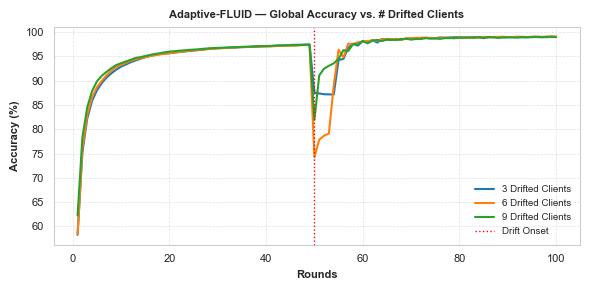

In [12]:
import os
import json
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------ Style ------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7
})
sns.set_style("whitegrid")

# ------------------ Config ------------------
DRIFT_ROUND = 50  # adjust if different in your experiments

# Directory that contains the 3 files:
# mnist_adaptive-fluid_results_3.json
# mnist_adaptive-fluid_results_6.json
# mnist_adaptive-fluid_results_9.json
clients_dir = os.path.join(plot_dir, "clients")

# Collect relevant JSON files
json_files = sorted(
    f for f in os.listdir(clients_dir)
    if f.startswith("mnist_adaptive-fluid_results_") and f.endswith(".json")
)

series = []  # list of (round_nums, mean_acc, label)

for file in json_files:
    file_path = os.path.join(clients_dir, file)

    # Extract number of drifted clients from filename
    # "mnist_adaptive-fluid_results_3.json" -> "3"
    num_drift_str = file.replace("mnist_adaptive-fluid_results_", "").replace(".json", "")
    label = f"{num_drift_str} Drifted Clients"

    # -------- Load JSON --------
    with open(file_path, "r") as f:
        results = json.load(f)

    # -------- Collect eval accuracies per round (all clients) --------
    round_to_accs = {}

    for client_id, rounds in results.items():
        # rounds: dict of {round_id: { ... "eval_metrics": "..." ... }}
        for r_str, round_data in rounds.items():
            r = int(r_str)
            metrics = ast.literal_eval(round_data["eval_metrics"])
            acc = metrics["accuracy"] * 100.0  # percentage

            round_to_accs.setdefault(r, []).append(acc)

    if not round_to_accs:
        continue

    # -------- Compute mean per round --------
    round_nums = sorted(round_to_accs.keys())
    mean_acc = [np.mean(round_to_accs[r]) for r in round_nums]

    series.append((round_nums, mean_acc, label))

# ------------------ Plot ------------------
fig, ax = plt.subplots(figsize=(6, 3))

colors = sns.color_palette("tab10", len(series))

for i, (round_nums, mean_acc, label) in enumerate(series):
    ax.plot(
        round_nums,
        mean_acc,
        linewidth=1.5,
        color=colors[i],
        label=label,
    )

# Drift marker
ax.axvline(x=DRIFT_ROUND, color="red", linewidth=1, linestyle=":", label="Drift Onset")

# Formatting
ax.set_title("Adaptive-FLUID — Global Accuracy vs. # Drifted Clients", fontweight="bold")
ax.set_xlabel("Rounds", fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontweight="bold")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.margins(y=0.05)

ax.legend(frameon=False)
plt.savefig("/Users/amankumar/Documents/MS/Sem4/Thesis/plots/drift_fraction_accuracy.pdf", format="pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd
import re

DRIFT_ROUND = 50  # must match your experiments

rows = []

for round_nums, mean_acc, label in series:
    # label looks like "3 Drifted Clients"
    match = re.search(r"(\d+)", label)
    num_drifted = int(match.group(1))

    # Convert to percentage of clients (assuming 10 total clients)
    drift_fraction = int((num_drifted / 10) * 100)

    # ---- Metrics ----
    final_acc = float(mean_acc[-1])  # last round accuracy

    # Find indices for round 49 and 50 safely
    r49_idx = round_nums.index(DRIFT_ROUND - 1)
    r50_idx = round_nums.index(DRIFT_ROUND)

    acc_49 = float(mean_acc[r49_idx])
    acc_50 = float(mean_acc[r50_idx])
    dip = acc_50 - acc_49

    rows.append({
        "drifted_clients": num_drifted,
        "drift_fraction_pct": drift_fraction,
        "accuracy_round_49_pct": round(acc_49, 2),
        "accuracy_round_50_pct": round(acc_50, 2),
        "dip_49_to_50_pct": round(dip, 2),
        "final_accuracy_pct": round(final_acc, 2),
    })

df_drift = (
    pd.DataFrame(rows)
      .sort_values("drifted_clients")
      .reset_index(drop=True)
)

df_drift

,drifted_clients,drift_fraction_pct,accuracy_round_49_pct,accuracy_round_50_pct,dip_49_to_50_pct,final_accuracy_pct
0,3,30,97.45,87.54,-9.91,98.98
1,6,60,97.32,74.30,-23.02,99.07
2,9,90,97.38,81.95,-15.43,98.94


# Kappa

In [15]:
plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/adaptive-fluid/fluid-fed-ul/src/plots/fmnist"

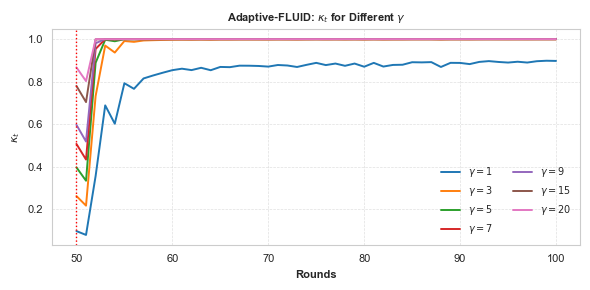

In [10]:
import os
import json
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------ Style ------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7
})
sns.set_style("whitegrid")

# ------------------ Config ------------------
adaptive_file = os.path.join(plot_dir, "fashion_mnist_adaptive-fluid_results.json")

DRIFT_ROUND = 50
DRIFTED_CLIENTS = {"0", "1", "3", "4", "5", "7", "9"}

GAMMAS = [1, 3, 5, 7, 9, 15, 20]

# ------------------ Load JSON ------------------
with open(adaptive_file, "r") as f:
    data = json.load(f)

# ------------------ Mean eval_acc_rrt per round (over drifted clients) ------------------
round_to_acc_rrt = {}

for client_id in DRIFTED_CLIENTS:
    if client_id not in data:
        continue

    for r_str, rdata in data[client_id].items():
        metrics = ast.literal_eval(rdata["eval_metrics"])

        if "eval_acc_rrt" not in metrics:
            continue

        r = int(r_str)
        round_to_acc_rrt.setdefault(r, []).append(float(metrics["eval_acc_rrt"]))

rounds = sorted(round_to_acc_rrt.keys())
mean_acc_rrt = np.array([np.mean(round_to_acc_rrt[r]) for r in rounds])  # [0,1]

# ------------------ Plot ------------------
fig, ax = plt.subplots(figsize=(6, 3))

colors = sns.color_palette("tab10", len(GAMMAS))

for gamma, color in zip(GAMMAS, colors):
    kappa = 1.0 - np.power((1.0 - mean_acc_rrt), gamma)

    ax.plot(
        rounds,
        kappa,
        linewidth=1.4,
        color=color,
        label=rf"$\gamma={gamma}$"
    )

# Drift marker
ax.axvline(x=DRIFT_ROUND, color="red", linestyle=":", linewidth=1)

# Formatting
ax.set_title(r"Adaptive-FLUID: $\kappa_t$ for Different $\gamma$", fontweight="bold")
ax.set_xlabel("Rounds", fontweight="bold")
ax.set_ylabel(r"$\kappa_t$", fontweight="bold")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.margins(y=0.05)

ax.legend(frameon=False, ncol=2)
plt.savefig("/Users/amankumar/Documents/MS/Sem4/Thesis/plots/k_gamma.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()


# Recovery rounds

In [8]:
plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/adaptive-fluid/fluid-fed-ul/src/plots/"

In [9]:
import os
import json
import ast
import numpy as np
import pandas as pd

# ------------------ Config ------------------
PLOT_DIR = plot_dir
DATASETS = ["mnist", "fmnist", "cifar"]

DRIFT_ROUND = 50                  # for Δ-from-drift column
USE_DRIFTED_CLIENTS = False       # True if you want mean over only drifted clients
DRIFTED_CLIENTS = {"0", "1", "3", "4", "5", "7", "9"}  # used only if USE_DRIFTED_CLIENTS=True

label_map = {
    "drift": "FedAvg",            # IMPORTANT: your FedAvg mode seems to be called "drift"
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID"
}

# ------------------ Helpers ------------------
def extract_method(filename: str) -> str:
    """
    Converts filename to a method name using label_map.
    Handles prefixes like mnist_/fashion_mnist_/cifar10_.
    """
    name = filename.replace("_results.json", "")
    name = name.replace("fashion_mnist_", "").replace("mnist_", "").replace("cifar10_", "").replace("fmnist_", "")
    return label_map.get(name.lower(), name.capitalize())

def mean_accuracy_curve(data: dict):
    """
    Returns (round_nums_sorted, mean_acc_percent_per_round) using eval_metrics["accuracy"].
    Mean is across clients present in JSON (or drifted only if enabled).
    """
    round_to_accs = {}

    client_ids = list(data.keys())
    if USE_DRIFTED_CLIENTS:
        client_ids = [cid for cid in client_ids if cid in DRIFTED_CLIENTS]

    for cid in client_ids:
        for r_str, rdata in data[cid].items():
            r = int(r_str)
            metrics = ast.literal_eval(rdata["eval_metrics"])
            acc = float(metrics["accuracy"]) * 100.0
            round_to_accs.setdefault(r, []).append(acc)

    rounds = sorted(round_to_accs.keys())
    mean_acc = np.array([np.mean(round_to_accs[r]) for r in rounds], dtype=float)
    return rounds, mean_acc

def first_cross_round_after_drift(rounds, acc, threshold, t_start):
    """
    First round r >= t_start where acc >= threshold.
    """
    for r, a in zip(rounds, acc):
        if r >= t_start and a >= threshold:
            return r
    return None

# ------------------ Main ------------------
rows = []

for dataset in DATASETS:
    dataset_dir = os.path.join(PLOT_DIR, dataset)
    json_files = [f for f in os.listdir(dataset_dir) if f.endswith(".json")]

    # ---- 1) Find FedAvg final accuracy for this dataset ----
    fedavg_file = None
    for f in json_files:
        if extract_method(f) == "FedAvg":
            fedavg_file = f
            break

    if fedavg_file is None:
        # If FedAvg file isn't found, skip dataset (or you can raise)
        continue

    with open(os.path.join(dataset_dir, fedavg_file), "r") as f:
        fedavg_data = json.load(f)

    fedavg_rounds, fedavg_mean_acc = mean_accuracy_curve(fedavg_data)
    fedavg_final = float(fedavg_mean_acc[-1])

    # ---- 2) For every method, compute first crossing of FedAvg final ----
    for file in sorted(json_files):
        method = extract_method(file)

        with open(os.path.join(dataset_dir, file), "r") as f:
            data = json.load(f)

        rounds, mean_acc = mean_accuracy_curve(data)

        cross_r = first_cross_round_after_drift(
                        rounds,
                        mean_acc,
                        fedavg_final,
                        DRIFT_ROUND
                    )

        rows.append({
            "Dataset": dataset.upper(),
            "Method": method,
            "FedAvg Final Accuracy (%)": round(fedavg_final, 2),
            "First Cross Round (>= FedAvg final)": cross_r,
            "Cross Rounds Δ from Drift": None if cross_r is None else cross_r - DRIFT_ROUND,
            "Method Final Accuracy (%)": round(float(mean_acc[-1]), 2),
            "Gap vs FedAvg Final (%)": round(float(mean_acc[-1]) - fedavg_final, 2),
        })

df_cross_fedavg_final = (
    pd.DataFrame(rows)
      .sort_values(["Dataset", "First Cross Round (>= FedAvg final)"], ascending=[True, True])
      .reset_index(drop=True)
)

df_cross_fedavg_final

,Dataset,Method,FedAvg Final Accuracy (%),First Cross Round (>= FedAvg final),Cross Rounds Δ from Drift,Method Final Accuracy (%),Gap vs FedAvg Final (%)
0,CIFAR,RRT,48.60,57.0,7.0,64.04,15.44
1,CIFAR,Adaptive-FLUID,48.60,60.0,10.0,62.94,14.35
2,CIFAR,FedAvg,48.60,72.0,22.0,48.60,0.00
3,CIFAR,FedAU,48.60,76.0,26.0,49.25,0.65
4,CIFAR,FLUID,48.60,80.0,30.0,49.03,0.43
5,CIFAR,Retraining,48.60,NaN,NaN,47.19,-1.41
6,FMNIST,RRT,76.26,55.0,5.0,87.92,11.66
7,FMNIST,Adaptive-FLUID,76.26,58.0,8.0,88.18,11.92
8,FMNIST,FLUID,76.26,73.0,23.0,76.73,0.47
9,FMNIST,FedAU,76.26,74.0,24.0,76.49,0.23


# AUC

In [2]:
plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/adaptive-fluid/fluid-fed-ul/src/plots/"

[MNIST] methods found: ['Adaptive-FLUID', 'FLUID', 'FedAU', 'FedAvg', 'RRT', 'Retraining']
[FMNIST] methods found: ['Adaptive-FLUID', 'FLUID', 'FedAU', 'FedAvg', 'RRT', 'Retraining']
[CIFAR] methods found: ['Adaptive-FLUID', 'FLUID', 'FedAU', 'FedAvg', 'RRT', 'Retraining']

AUC table:
 Dataset         CIFAR  FMNIST  MNIST
Method                              
Retraining       42.4    72.7   82.4
FedAvg           48.3    75.5   85.2
FedAU            48.1    75.7   85.6
FLUID            48.1    75.8   85.7
RRT              57.5    81.9   95.2
Adaptive-FLUID   57.7    83.8   96.9


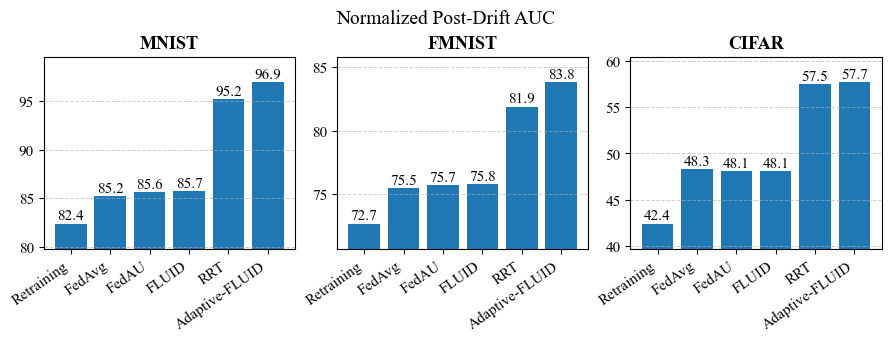

In [3]:
import os
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================= CONFIG =================
PLOT_DIR = plot_dir
DATASET_FOLDERS = {"mnist": "MNIST", "fmnist": "FMNIST", "cifar": "CIFAR"}
T_DRIFT = 50

label_map = {
    "drift": "FedAvg",
    "retraining": "Retraining",
    "rapid-retraining": "RRT",
    "fedau": "FedAU",
    "fluid": "FLUID",
    "adaptive-fluid": "Adaptive-FLUID",
}

methods_order = [
    "Retraining",
    "FedAvg",
    "FedAU",
    "FLUID",
    "RRT",
    "Adaptive-FLUID",
]

# ================ HELPERS =================
def method_from_filename(fname: str) -> str:
    base = fname.replace("_results.json", "").lower()
    base = (base
            .replace("mnist_", "")
            .replace("fashion_mnist_", "")
            .replace("cifar10_", "")
            .replace("fashion_", "")
           )
    return label_map.get(base, base.capitalize())

def mean_accuracy_curve(data: dict):
    round_to_acc = {}
    for cid, rounds in data.items():
        for r_str, rdata in rounds.items():
            r = int(r_str)
            metrics = ast.literal_eval(rdata["eval_metrics"])
            acc = float(metrics["accuracy"]) * 100.0
            round_to_acc.setdefault(r, []).append(acc)

    rounds_sorted = sorted(round_to_acc.keys())
    mean_acc = np.array([np.mean(round_to_acc[r]) for r in rounds_sorted], dtype=float)
    return rounds_sorted, mean_acc

def normalized_post_drift_auc(rounds, acc, t_start=50):
    rounds = np.array(rounds, dtype=float)
    acc = np.array(acc, dtype=float)

    mask = rounds >= t_start
    post_r = rounds[mask]
    post_a = acc[mask]

    if len(post_r) < 2:
        return np.nan  # keep NaN for missing/invalid cases

    auc = np.trapz(post_a, post_r)
    duration = post_r[-1] - post_r[0]
    if duration <= 0:
        return np.nan

    return float(auc / duration)

# ================ COMPUTE df_auc =================
records = []

for folder, ds_label in DATASET_FOLDERS.items():
    ds_dir = os.path.join(PLOT_DIR, folder)
    if not os.path.isdir(ds_dir):
        raise FileNotFoundError(f"Missing dataset folder: {ds_dir}")

    json_files = [f for f in os.listdir(ds_dir) if f.endswith(".json")]

    found_methods = []
    for file in sorted(json_files):
        method = method_from_filename(file)
        found_methods.append(method)

        file_path = os.path.join(ds_dir, file)
        with open(file_path, "r") as f:
            data = json.load(f)

        rounds, acc = mean_accuracy_curve(data)
        auc_norm = normalized_post_drift_auc(rounds, acc, T_DRIFT)

        records.append({
            "Dataset": ds_label,
            "Method": method,
            "AUC_norm": auc_norm,
        })

    print(f"[{ds_label}] methods found:", sorted(set(found_methods)))

df_long = pd.DataFrame(records)

df_auc = (
    df_long.pivot_table(index="Method", columns="Dataset", values="AUC_norm", aggfunc="first")
    .reindex(methods_order).round(1)
)

# Round for display (keep NaN)
df_auc_display = df_auc.round(2)
print("\nAUC table:\n", df_auc_display)

# ================ PLOT =================
datasets = ["MNIST", "FMNIST", "CIFAR"]
methods = list(df_auc_display.index)

FIG_WIDTH = 8.8
FIG_HEIGHT = 3.3

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT), constrained_layout=True)

for ax, ds in zip(axes, datasets):
    vals = df_auc_display[ds].astype(float).values

    # Drop NaNs for y-lims computation to avoid crashes
    vals_nonan = vals[~np.isnan(vals)]
    if len(vals_nonan) == 0:
        ax.set_title(ds)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue

    x = np.arange(len(methods))
    ax.bar(x, vals)

    vmin, vmax = float(np.min(vals_nonan)), float(np.max(vals_nonan))
    pad = max(0.08, (vmax - vmin) * 0.18)
    ax.set_ylim(vmin - pad, vmax + pad)

    for i, v in enumerate(vals):
        if np.isnan(v):
            continue
        ax.text(i, v + pad * 0.03, f"{v:.1f}",
                ha="center", va="bottom",
                fontsize=11)

    ax.set_title(ds, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=35, ha="right")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.6)

fig.suptitle("Normalized Post-Drift AUC", fontsize=14)
plt.savefig("/Users/amankumar/Documents/MS/Sem4/Thesis/plots/auc.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Sequence

In [66]:
plot_dir = "/Users/amankumar/Documents/MS/Sem4/Thesis/adaptive-fluid/fluid-fed-ul/src/plots/sequence"

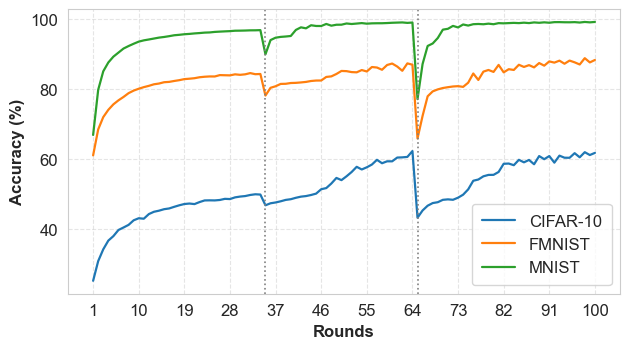

In [74]:
import os
import json
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------ Config ------------------
DRIFT_ROUND1 = 35
DRIFT_ROUND2 = 65


# ------------------ Style (IEEE-ish) ------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12
})
sns.set_style("whitegrid")

# ------------------ Helper: dataset label from filename ------------------
def dataset_from_filename(fname: str) -> str:
    f = fname.lower()
    if "fashion_mnist" in f or "fmnist" in f:
        return "FMNIST"
    if "cifar10" in f or "cifar-10" in f or "cifar" in f:
        return "CIFAR-10"
    if "mnist" in f:
        return "MNIST"
    return "Dataset"

# ------------------ Load 3 dataset JSONs ------------------
json_files = sorted([f for f in os.listdir(plot_dir) if f.endswith(".json")])

series = []  # (dataset_label, rounds, mean_acc_percent)

for file in json_files:
    file_path = os.path.join(plot_dir, file)
    ds_label = dataset_from_filename(file)

    with open(file_path, "r") as f:
        data = json.load(f)

    # Collect per-client accuracy curves
    client_accuracies = []
    for client_id, rounds in data.items():
        acc_list = []
        for round_id, round_data in sorted(rounds.items(), key=lambda x: int(x[0])):
            metrics = ast.literal_eval(round_data["eval_metrics"])
            acc_list.append(float(metrics["accuracy"]) * 100.0)
        client_accuracies.append(acc_list)

    # mean across clients (round-wise)
    avg_acc = np.mean(np.array(client_accuracies, dtype=float), axis=0)
    rounds = np.arange(1, len(avg_acc) + 1)

    series.append((ds_label, rounds, avg_acc))

# ------------------ Plot ------------------
plt.figure(figsize=(6.4, 3.6))  # IEEE double-column width
colors = sns.color_palette("tab10", len(series))

for i, (ds_label, rounds, acc_pct) in enumerate(series):
    plt.plot(
        rounds,
        acc_pct,
        label=ds_label,
        linewidth=1.6,
        color=colors[i]
    )

# Drift marker
plt.axvline(
    DRIFT_ROUND1,
    color="grey",
    linestyle=":",
    linewidth=1.2,
)

plt.axvline(
    DRIFT_ROUND2,
    color="grey",
    linestyle=":",
    linewidth=1.2,
)

plt.xlabel("Rounds", fontweight="bold")
plt.ylabel("Accuracy (%)", fontweight="bold")

# x ticks based on longest curve
max_len = max(len(s[1]) for s in series)
plt.xticks(ticks=np.linspace(1, max_len, 12, dtype=int))

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right", frameon=True, borderpad=0.6, framealpha=0.8)

plt.tight_layout()
plt.savefig("/Users/amankumar/Documents/MS/Sem4/Thesis/plots/sequential_drift_all_datasets.pdf", format="pdf", bbox_inches="tight")

plt.show()